# LTL Revenue Quality & Pricing Optimization
**End-to-end synthetic case study**

This notebook demonstrates data quality, ETL validation, KPI construction, root-cause analysis, expected-revenue modeling, anomaly prioritization, customer-lane segmentation and pricing simulation.

> **Disclosure:** No confidential FedEx data is used. Dillard's is included only as a publicly documented historical FedEx Freight customer reference; all shipment/account economics are synthetic. Other account names are fictional.


In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

ROOT=Path("..") if Path.cwd().name=="notebooks" else Path(".")
raw=pd.read_csv(ROOT/"data/raw/universal_shipments_raw.csv.gz",parse_dates=["ship_date","ingestion_ts"])
classes=pd.read_csv(ROOT/"data/reference/dim_freight_class.csv")
customers=pd.read_csv(ROOT/"data/reference/dim_customer.csv")
terminals=pd.read_csv(ROOT/"data/reference/dim_terminal.csv")
raw.shape


(220420, 30)

## 1. Data-quality assessment
The raw universal dataset deliberately contains defects that should be caught before financial analysis.

In [2]:
dq_before=pd.Series({
"rows":len(raw),
"duplicate_shipment_rows":raw.duplicated("shipment_id").sum(),
"missing_weight":raw.weight_lbs.isna().sum(),
"nonpositive_weight":(raw.weight_lbs<=0).sum(),
"invalid_class":(~raw.freight_class.isin(classes.freight_class)).sum(),
"missing_customer_id":raw.customer_id.isna().sum()
})
dq_before


rows                       220420
duplicate_shipment_rows       420
missing_weight                653
nonpositive_weight             90
invalid_class                 352
missing_customer_id           281
dtype: int64

## 2. ETL / repair rules
Deduplicate by latest ingestion timestamp; recover customer ID from governed name mapping; repair invalid weights using customer×class/class medians; repair invalid class from nearest density midpoint.

In [3]:
clean=raw.sort_values("ingestion_ts").drop_duplicates("shipment_id",keep="last").copy()
name_to_id=customers.set_index("customer_name").customer_id
m=clean.customer_id.isna()
clean.loc[m,"customer_id"]=clean.loc[m,"customer_name"].map(name_to_id)

clean["weight_lbs"]=clean.weight_lbs.where(clean.weight_lbs>0)
clean["weight_lbs"]=clean.weight_lbs.fillna(clean.groupby(["customer_id","freight_class"]).weight_lbs.transform("median"))
clean["weight_lbs"]=clean.weight_lbs.fillna(clean.groupby("freight_class").weight_lbs.transform("median")).fillna(clean.weight_lbs.median())

class_vals=classes.freight_class.to_numpy(); mids=classes.density_mid.to_numpy()
bad=~clean.freight_class.isin(class_vals)
clean.loc[bad,"freight_class"]=class_vals[np.argmin(abs(clean.loc[bad,"density_lbs_cuft"].to_numpy()[:,None]-mids[None,:]),axis=1)]

dq_after=pd.Series({
"rows":len(clean),
"duplicate_shipment_rows":clean.duplicated("shipment_id").sum(),
"missing_weight":clean.weight_lbs.isna().sum(),
"nonpositive_weight":(clean.weight_lbs<=0).sum(),
"invalid_class":(~clean.freight_class.isin(class_vals)).sum(),
"missing_customer_id":clean.customer_id.isna().sum()
})
pd.concat([dq_before.rename("before"),dq_after.rename("after")],axis=1)


,before,after
rows,220420,220000
duplicate_shipment_rows,420,0
missing_weight,653,0
nonpositive_weight,90,0
invalid_class,352,0
missing_customer_id,281,0


## 3. Revenue-quality KPI layer

In [4]:
clean["revenue_gap"]=np.maximum(clean.expected_revenue-clean.billed_revenue,0)
clean["pricing_realization"]=clean.billed_revenue/clean.expected_revenue
clean["revenue_per_cwt"]=clean.billed_revenue/(clean.weight_lbs/100)
clean["contribution"]=clean.billed_revenue-clean.estimated_cost
clean["contribution_margin"]=clean.contribution/clean.billed_revenue

pd.Series({
"shipments":clean.shipment_id.nunique(),
"revenue":clean.billed_revenue.sum(),
"revenue_gap":clean.revenue_gap.sum(),
"pricing_realization":clean.billed_revenue.sum()/clean.expected_revenue.sum(),
"contribution":clean.contribution.sum()
})


shipments              2.200000e+05
revenue                7.584235e+07
revenue_gap            1.369383e+06
pricing_realization    9.879073e-01
contribution          -1.028396e+08
dtype: float64

## 4. Root-cause validation
Because this is a synthetic portfolio project, planted issue labels let us verify that the workflow surfaces known commercial problems. A production system would infer root cause from governed transaction and contract data.

In [5]:
root=(clean[clean.injected_issue!="None"].groupby("injected_issue",as_index=False)
      .agg(shipments=("shipment_id","nunique"),revenue_gap=("revenue_gap","sum"))
      .sort_values("revenue_gap",ascending=False))
root


,injected_issue,shipments,revenue_gap
8,Outdated contract discount,4206,139676.12
7,Missing residential charge,1170,139210.31
3,Long-haul lane underpricing,3542,137120.18
6,Missing liftgate charge,1603,133013.36
1,Freight class mismatch,2767,107782.90
4,Missing appointment charge,1147,60633.10
5,Missing extreme-length charge,159,33406.92
0,Excess discretionary discount,1122,29083.47
2,Lane-specific pricing gap,363,8606.77


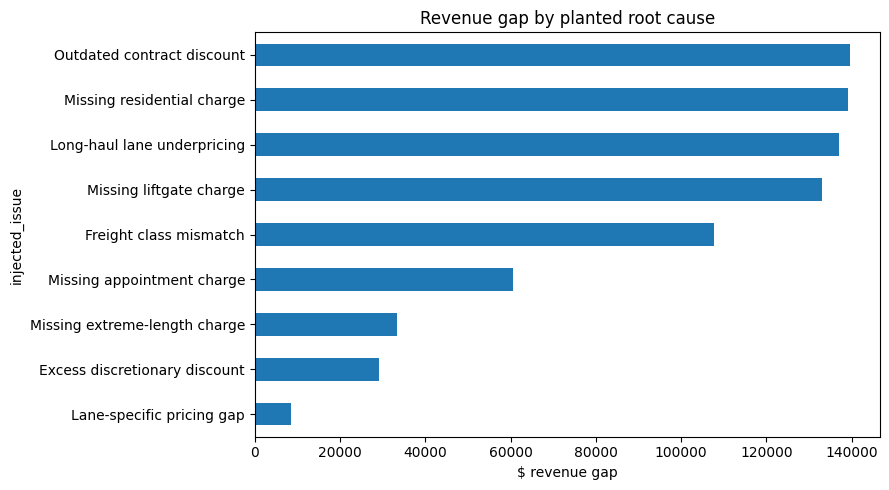

In [6]:
ax=root.sort_values("revenue_gap").plot.barh(x="injected_issue",y="revenue_gap",legend=False,figsize=(9,5),title="Revenue gap by planted root cause")
ax.set_xlabel("$ revenue gap"); plt.tight_layout()


## 5. Customer × lane prioritization
High-volume cells with weak realization are the most actionable starting point because they combine materiality with repeatable economics.

In [7]:
cells=clean.groupby(["customer_id","customer_name","lane_id"],as_index=False).agg(
shipments=("shipment_id","nunique"),revenue=("billed_revenue","sum"),expected=("expected_revenue","sum"),
gap=("revenue_gap","sum"),contribution=("contribution","sum"))
cells["realization"]=cells.revenue/cells.expected
targets=cells[(cells.shipments>=80)&(cells.realization<.965)].sort_values("gap",ascending=False).head(20)
targets.head(10)


,customer_id,customer_name,lane_id,shipments,revenue,expected,gap,contribution,realization
925,C004,Summit Auto Components,T14_T11,86,29839.42,31040.37,1347.50,-60382.87,0.961310
822,C004,Summit Auto Components,T07_T14,91,28612.13,29763.25,1256.41,-6171.41,0.961324
32,C001,Dillard's,T03_T04,116,30875.23,31996.58,1217.08,-9281.35,0.964954


## 6. Expected-revenue model
Train only on near-normal shipments so the model learns healthy economics rather than reproducing leakage.

In [8]:
sample=clean.sample(80000,random_state=42)
features=["weight_lbs","distance_miles","freight_class","pallet_count","density_lbs_cuft","fuel_surcharge_pct",
          "customer_id","origin_terminal_id","destination_terminal_id","service_level"]
train=sample[sample.pricing_realization>=.985]
num=["weight_lbs","distance_miles","freight_class","pallet_count","density_lbs_cuft","fuel_surcharge_pct"]
cat=["customer_id","origin_terminal_id","destination_terminal_id","service_level"]
pre=ColumnTransformer([
("num",SimpleImputer(strategy="median"),num),
("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]),cat)
])
model=Pipeline([("pre",pre),("reg",HistGradientBoostingRegressor(max_iter=150,learning_rate=.08,max_leaf_nodes=31,l2_regularization=1.0,random_state=42))])
Xtr,Xte,ytr,yte=train_test_split(train[features],train.expected_revenue,test_size=.2,random_state=42)
model.fit(Xtr,ytr); pred=model.predict(Xte)
{"MAE":mean_absolute_error(yte,pred),"R2":r2_score(yte,pred)}


{'MAE': 51.769941059378205, 'R2': 0.9214264693217635}

## 7. Pricing scenario simulation
The scenario uses illustrative elasticity. The decision objective is incremental contribution, not simply higher billed revenue.

In [9]:
rows=[]
for p in [.01,.02,.03,.04,.05]:
    for r in targets.itertuples():
        seg=customers.set_index("customer_id").loc[r.customer_id,"segment"]
        elasticity=-.85 if seg=="Enterprise" else -1.05
        vc=elasticity*p
        new_rev=r.revenue*(1+p)*(1+vc)
        new_contrib=new_rev-(r.revenue-r.contribution)*(1+vc)
        rows.append((p,vc,new_rev-r.revenue,new_contrib-r.contribution))
scenario=pd.DataFrame(rows,columns=["price_action","expected_volume_change","incremental_revenue","incremental_contribution"])
summary=scenario.groupby("price_action",as_index=False)[["incremental_revenue","incremental_contribution"]].sum()
summary["expected_volume_change"]=scenario.groupby("price_action").expected_volume_change.mean().values
summary


,price_action,incremental_revenue,incremental_contribution,expected_volume_change
0,0.01,126.397394,1530.277879,-0.0085
1,0.02,237.609235,3045.370205,-0.0170
2,0.03,333.635523,4545.276978,-0.0255
3,0.04,414.476259,6029.998199,-0.0340
4,0.05,480.131443,7499.533867,-0.0425


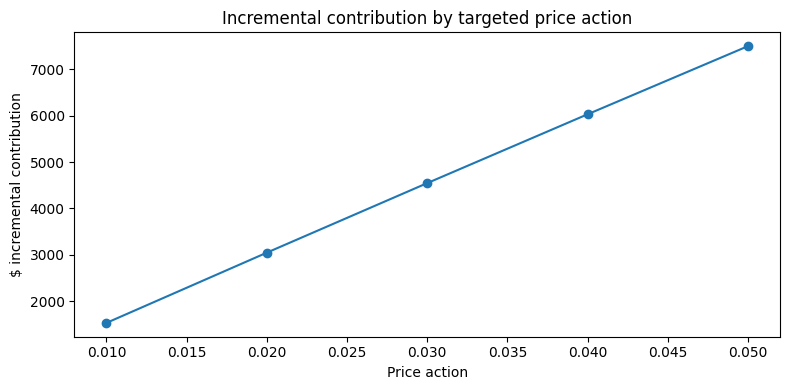

In [10]:
ax=summary.plot(x="price_action",y="incremental_contribution",marker="o",legend=False,figsize=(8,4),title="Incremental contribution by targeted price action")
ax.set_xlabel("Price action"); ax.set_ylabel("$ incremental contribution"); plt.tight_layout()


## 8. Executive recommendation
1. **Do not use a blanket price increase.** Prioritize customer-lane cells with high materiality and weak realization.
2. **Separate defect recovery from commercial repricing.** Missing accessorials/classification errors need process controls; outdated discounts/lane gaps need pricing review.
3. **Pilot targeted actions for 60–90 days** with matched controls and monitor realization, revenue/CWT, contribution, volume retention and customer exceptions.
4. **Operationalize anomaly detection** as a triage queue, with analyst review and governed contract/rating data.
5. **Before production**, estimate elasticity from actual historical behavior and enforce contract/customer constraints.
